In [1]:
#Thomas Howard IV

#Import the packages needed
import nfl_data_py as nfl
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Only using the data from 2016 to 2022
seasons = range(2016,2022 + 1)
pbp_py = nfl.import_pbp_data(seasons)

2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
Downcasting floats.


In [3]:
#Filter for run data only
is_run = pbp_py['play_type'] == 'run'
has_rusher = pbp_py['rusher_id'].notna()
has_down = pbp_py['down'].notna()
has_location = pbp_py['run_location'].notna()

# Combine filters and reset index
pbp_py_run = pbp_py[is_run & has_rusher & has_down & has_location].reset_index(drop=True)

In [4]:
#set null values to 0
pbp_py_run['rushing_yards'] = pbp_py_run['rushing_yards'].fillna(0)

In [5]:
#set theme for the plots
sns.set_theme(style="whitegrid", palette = "colorblind")

In [6]:
#Change down to be an integer
pbp_py_run['down'] = pbp_py_run['down'].astype(str)

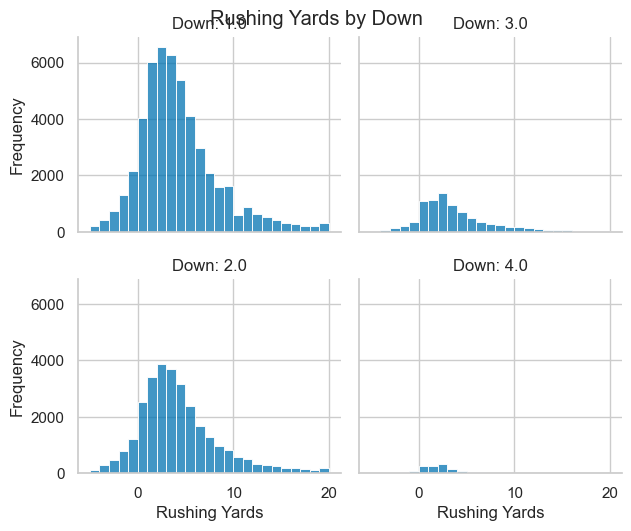

In [7]:
#Plot rushing yards by down

#Create a 2x2 grid that has a plot for each down
g = sns.FacetGrid(data=pbp_py_run, col="down", col_wrap=2, height=2.7, aspect=1.2)

g.map_dataframe(
    sns.histplot, 
    x="rushing_yards", 
    binwidth=1, 
    binrange=(-5, 20),
)
g.set_axis_labels("Rushing Yards", "Frequency")
g.set_titles("Down: {col_name}")
g.tight_layout()
g.fig.suptitle("Rushing Yards by Down")

plt.show()

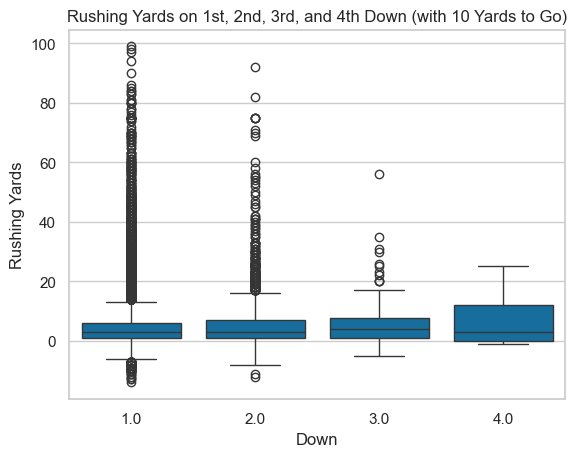

In [8]:
#Create plot for situations where ydstogo = 10 

#Creating dataframe for 10 yards to go
pbp_10_yds = pbp_py_run[pbp_py_run['ydstogo'] == 10]

#Creating the boxplot
plt.figure()
sns.boxplot(
    data=pbp_10_yds,
    x="down",
    y="rushing_yards" 
)

plt.title("Rushing Yards on 1st, 2nd, 3rd, and 4th Down (with 10 Yards to Go)")
plt.xlabel("Down")
plt.ylabel("Rushing Yards")

plt.show()

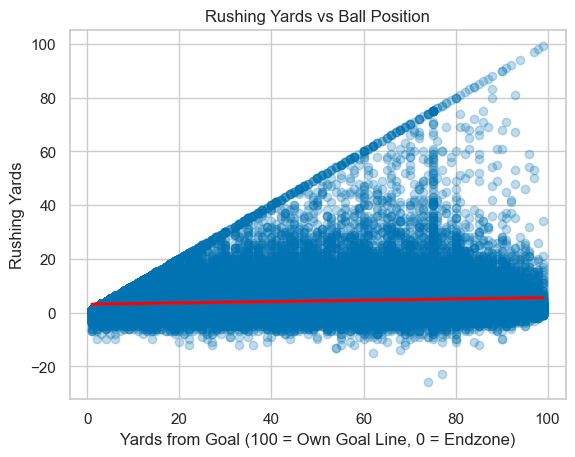

In [9]:
#Create plot of yards to the endzone 

sns.regplot(
    data=pbp_py_run,
    x="yardline_100",
    y="rushing_yards",
    scatter_kws={"alpha": 0.25},
    line_kws = {"color":"red"}
)
plt.title("Rushing Yards vs Ball Position")
plt.xlabel("Yards from Goal (100 = Own Goal Line, 0 = Endzone)")
plt.ylabel("Rushing Yards")
plt.show()

In [10]:
#Group and calculate the average rushing yards by distance from goal
pbp_py_run_y100 = pbp_py_run.groupby("yardline_100")["rushing_yards"].mean().reset_index()

In [11]:
pbp_py_run_y100.columns = ['yardline_100', 'avg_rushing_yards']

In [12]:
pbp_py_run_y100 = pbp_py_run_y100.reset_index()

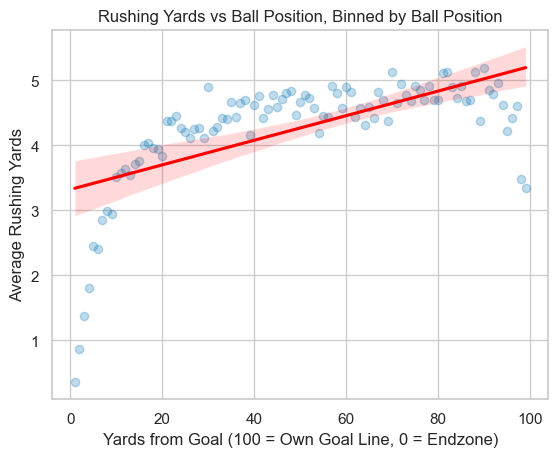

In [13]:
#Create plot to show ball position and rushing yards binned by yards
sns.regplot(
    data=pbp_py_run_y100,
    x="yardline_100",
    y="avg_rushing_yards",
    scatter_kws = {"alpha":0.25},
    line_kws={"color":"red"}
)
plt.title("Rushing Yards vs Ball Position, Binned by Ball Position")
plt.xlabel("Yards from Goal (100 = Own Goal Line, 0 = Endzone)")
plt.ylabel("Average Rushing Yards")
plt.show()

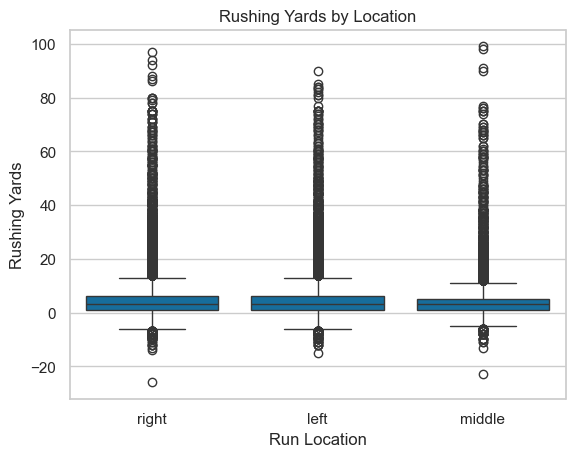

In [14]:
#Create boxplot for rushing yards by locations
sns.boxplot(data=pbp_py_run,
            x="run_location",
            y="rushing_yards")
plt.title("Rushing Yards by Location")
plt.xlabel("Run Location")
plt.ylabel("Rushing Yards")
plt.show()

In [15]:
# Group by score differential and calculate the average rushing yards
pbp_py_run_sd = pbp_py_run.groupby("score_differential")["rushing_yards"].mean().reset_index()

In [16]:
#Naming columns
pbp_py_run_sd.columns = ['score_differential', 'avg_rushing_yards']

In [17]:
pbp_py_run_sd = pbp_py_run_sd.reset_index(drop=True)

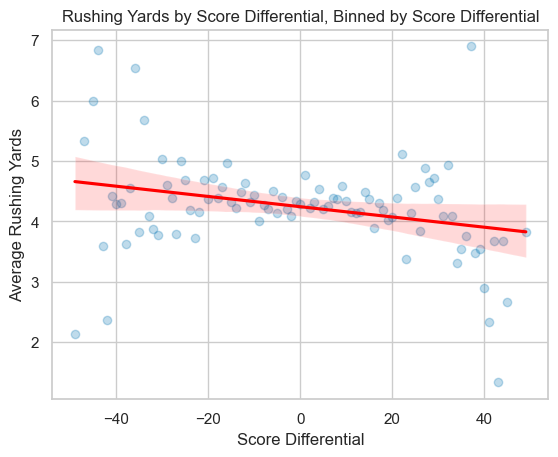

In [18]:
#Creating plot for score differential and rushing yards. binned by score differential
sns.regplot(
    data=pbp_py_run_sd,
    x="score_differential",
    y="avg_rushing_yards",
    scatter_kws={"alpha":0.25},
    line_kws={"color" : "red"}
)
plt.title("Rushing Yards by Score Differential, Binned by Score Differential")
plt.xlabel("Score Differential")
plt.ylabel("Average Rushing Yards")
plt.show()

In [19]:
#Convert down to string
pbp_py_run['down'] = pbp_py_run['down'].astype(str)

In [20]:
#Create model for regression
formula = """
    rushing_yards ~ 1 + down + ydstogo + down:ydstogo + 
    yardline_100 + run_location + score_differential
"""
#Fit the OLS regression model
expected_yards_py = smf.ols(formula=formula, data=pbp_py_run).fit()

In [21]:
pbp_py_run['ryoe'] = expected_yards_py.resid

C:\Users\tehow\AppData\Local\Temp\ipykernel_19164\2221238682.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pbp_py_run['ryoe'] = expected_yards_py.resid


In [22]:
print(expected_yards_py.summary())

                            OLS Regression Results                            
Dep. Variable:          rushing_yards   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     136.6
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          4.53e-313
Time:                        08:15:25   Log-Likelihood:            -2.9760e+05
No. Observations:               91430   AIC:                         5.952e+05
Df Residuals:                   91418   BIC:                         5.953e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1

In [23]:
#Group by season and player to calculate season long RYOE stats
ryoe_py = pbp_py_run.groupby(['season', 'rusher_id', 'rusher']).agg(
    ryoe_count=('ryoe', 'count'),
    ryoe_sum=('ryoe', 'sum'),
    ryoe_avg=('ryoe', 'mean'),
    actual_avg=('rushing_yards', 'mean')
).reset_index()

In [24]:
# Rename columns
column_map = {
    "ryoe_count": "n",
    "ryoe_sum": "ryoe_total",
    "ryoe_avg": "ryoe_per",
    "actual_avg": "yards_per_carry"
}

#Apply the rename to players with more than 50 rushes
ryoe_py = ryoe_py.rename(columns=column_map)
ryoe_py = ryoe_py[ryoe_py['n'] > 50]

In [25]:
#Sort by the most total value added (RYOE Total)
ryoe_leaders = ryoe_py.sort_values("ryoe_total", ascending=False)
ryoe_leaders.head(10)

,season,rusher_id,rusher,n,ryoe_total,ryoe_per,yards_per_carry
1869,2021,00-0036223,J.Taylor,332,471.373827,1.419801,5.454819
1349,2020,00-0032764,D.Henry,395,346.025400,0.876014,5.232912
1182,2019,00-0034796,L.Jackson,126,328.580099,2.607779,6.880952
1069,2019,00-0032764,D.Henry,386,311.725168,0.807578,5.145078
1382,2020,00-0033293,A.Jones,221,301.833172,1.365761,5.565611
2102,2022,00-0034796,L.Jackson,72,280.787224,3.899823,7.930555
1032,2019,00-0031687,R.Mostert,190,274.136506,1.442824,5.831579
294,2016,00-0033045,E.Elliott,342,273.642527,0.800124,5.137427
1466,2020,00-0034796,L.Jackson,118,258.120643,2.187463,6.415254
1787,2021,00-0034791,N.Chubb,228,248.178676,1.088503,5.521930


In [26]:

#Sort by efficiency
ryoe_efficiency_leaders = ryoe_py.sort_values("ryoe_per", ascending=False)

#Show top ten most efficient rushers
ryoe_efficiency_leaders.head(10)

,season,rusher_id,rusher,n,ryoe_total,ryoe_per,yards_per_carry
2102,2022,00-0034796,L.Jackson,72,280.787224,3.899823,7.930555
1182,2019,00-0034796,L.Jackson,126,328.580099,2.607779,6.880952
1209,2019,00-0035228,K.Murray,53,137.662325,2.597402,6.867925
2238,2022,00-0036945,J.Fields,77,177.446564,2.304501,6.506494
1466,2020,00-0034796,L.Jackson,118,258.120643,2.187463,6.415254
348,2017,00-0027939,C.Newton,92,191.287297,2.079210,6.173913
1497,2020,00-0035228,K.Murray,70,143.928563,2.056122,6.057143
1784,2021,00-0034750,R.Penny,119,241.616559,2.030391,6.294117
1160,2019,00-0034400,J.Wilkins,51,97.781186,1.917278,6.019608
2036,2022,00-0033357,T.Hill,95,171.251682,1.802649,6.052631


In [27]:
#only keep columns wanted
cols_keep =["season","rusher_id", "rusher",
            "ryoe_per", "yards_per_carry"]

In [28]:
ryoe_now_py = ryoe_py[cols_keep].copy()

In [29]:
ryoe_last_py = ryoe_py[cols_keep].copy()

In [30]:
#Rename columns
ryoe_last_py = ryoe_last_py.rename(columns={
    'ryoe_per': 'ryoe_per_last',
    'yards_per_carry': 'yards_per_carry_last'
})

In [31]:
#Add +1 to season
ryoe_last_py["season"] += 1

In [32]:
#Merge the two years of data on player identifiers and season
ryoe_lag_py = ryoe_now_py.merge(
    ryoe_last_py,
    on=['rusher_id', 'rusher', 'season'],
    how='inner'
)

In [33]:
#Examine Correlation for yards per carry
ryoe_lag_py[["yards_per_carry_last", "yards_per_carry"]].corr()

,yards_per_carry_last,yards_per_carry
yards_per_carry_last,1.00000,0.34819
yards_per_carry,0.34819,1.00000


In [34]:
#Repeat with RYOE
ryoe_lag_py[["ryoe_per_last", "ryoe_per"]].corr()

,ryoe_per_last,ryoe_per
ryoe_per_last,1.000000,0.373985
ryoe_per,0.373985,1.000000
